### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Principal Component Analysis Jupyter Notebook

Principal Component Analysis


### Link to each Dataset:

### ECI Petitions:
#### 2024

- ECI 01: https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en Ban on conversion practices in the European Union
- ECI 02: https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe
- ECI 03: https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en My Voice, My Choice: For Safe And Accessible Abortion
- ECI 04: https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en Air-Quotas
- ECI 05: https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en Stop Destroying Videogames
- ECI 06: https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en Stop Cruelty Stop Slaughter
- ECI 07: https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en STOP FAKE FOOD: ORIGIN ON LABEL
- ECI 08: https://citizens-initiative.europa.eu/initiatives/details/2024/000010_en ECI for a Water-Smart and Resilient Europe
- ECI 09: https://citizens-initiative.europa.eu/initiatives/details/2024/000011_en PsychedeliCare

#### 2023

- ECI 10: https://citizens-initiative.europa.eu/initiatives/details/2023/000001_en Stop torture and inhuman treatment at Europe’s borders
- ECI 11: https://citizens-initiative.europa.eu/initiatives/details/2023/000002_en Ensuring a dignified reception of migrants in Europe
- ECI 12: https://citizens-initiative.europa.eu/initiatives/details/2023/000003_en End The Horse Slaughter Age
- ECI 13: https://citizens-initiative.europa.eu/initiatives/details/2023/000004_en Connecting all European capitals and people through a high-speed train network
- ECI 14: https://citizens-initiative.europa.eu/initiatives/details/2023/000005_en Effective implementation of the concept of judicial precedent in EU countries
- ECI 15: https://citizens-initiative.europa.eu/initiatives/details/2023/000006_en Taxing great wealth to finance the ecological and social transition
- ECI 16: https://citizens-initiative.europa.eu/initiatives/details/2023/000007_en Preservation and development of Ukrainian culture, education, language, and traditions in EU states
- ECI 17: https://citizens-initiative.europa.eu/initiatives/details/2023/000008_en EU Live Bus Stop Info
- ECI 18: https://citizens-initiative.europa.eu/initiatives/details/2023/000009_en Trust and Freedom
- ECI 19: https://citizens-initiative.europa.eu/initiatives/details/2023/000011_en Creation of a European Environment Authority

#### 2022

- ECI 20: https://citizens-initiative.europa.eu/initiatives/details/2022/000001_en Win It On The Pitch 
- ECI 21: https://citizens-initiative.europa.eu/initiatives/details/2022/000002_en Fur Free Europe
- ECI 22: https://citizens-initiative.europa.eu/initiatives/details/2022/000003_en End The Slaughter Age
- ECI 23: https://citizens-initiative.europa.eu/initiatives/details/2022/000004_en Good Clothes, Fair Pay
- ECI 24: https://citizens-initiative.europa.eu/initiatives/details/2022/000007_en Protect the EU’s Rural Heritage, Food Security and Supply
- ECI 25: https://citizens-initiative.europa.eu/initiatives/details/2022/000008_en Focus on Specific Learning Disabilities on EU Level
- ECI 26: https://citizens-initiative.europa.eu/initiatives/details/2022/000009_en European Citizens’ Initiative for VEGAN MEAL
- ECI 27: https://citizens-initiative.europa.eu/initiatives/details/2022/000010_en European Day of "Whatever it Takes" 

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### 2023 Global Development and Prosperity Index 
https://www.kaggle.com/datasets/tarktunataalt/2023-global-country-development-and-prosperity-index

### Media Literacy Index Dataset 2023
https://osis.bg/wp-content/uploads/2023/06/MLI-report-in-English-22.06.pdf

https://osis.bg/?p=4450&lang=en

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

### Import Libraries

In [244]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor

# https://www.geeksforgeeks.org/data-analysis/factor-analytics/
from factor_analyzer import calculate_bartlett_sphericity, calculate_kmo 


### Model Path 

Model path for exporting

In [245]:
model_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models"

### Output Path

In [246]:
output_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/outputs"

### Load Dataset

In [247]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "master_dataset.csv"
successful_file_name = "successful_master_dataset.csv"
complete_file_name = file_path + file_name
complete_successful_file_name = file_path + successful_file_name

In [248]:
master = pd.read_csv(complete_file_name)

In [249]:
successful_master = pd.read_csv(complete_successful_file_name)

## Log Transform of Signatures Per Capita

This is for the log regression version of each pca regression

### Master Dataset 
Master dataset contains some zero values for signatures per capita

In [250]:
master["Log_Signatures_Per_Capita"] = np.log1p(
    master["Signatures_Per_Capita"]
)

### Successful Master Dataset

THe successful petitions contain 0 zero values for signatures per capita

In [251]:
successful_master["Log_Signatures_Per_Capita"] = np.log(
    successful_master["Signatures_Per_Capita"]
)

### Feature Selection for PCA 01

This model will use the master dataset

In [252]:
features = [
    "Population",
    "Population_Density",
    "GDP_Per_Capita",
    "Unemployment",
    "Tertiary_Enrollment",
    "Life_Expectancy",
    "Media_Literacy_Index",
    "Governance",
    "Social_Capital",
    "Personal_Freedom",
    "Education"
]

X = master[features]

### Checking Assumptions

#### Checking for missing values

In [253]:
print(X.isnull().sum())

Population              0
Population_Density      0
GDP_Per_Capita          0
Unemployment            0
Tertiary_Enrollment     0
Life_Expectancy         0
Media_Literacy_Index    0
Governance              0
Social_Capital          0
Personal_Freedom        0
Education               0
dtype: int64


#### Correlation Matrix

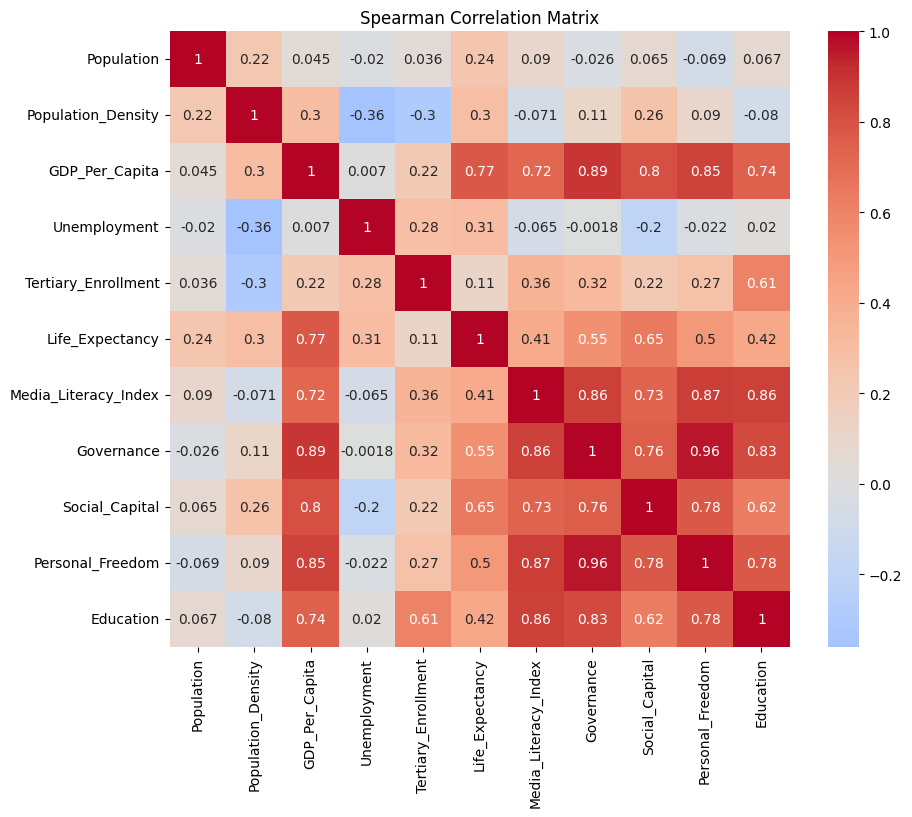

In [254]:
corr = X.corr(method="spearman")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix")

plt.show()

This matrix shows that each of my selected variables are highly correlated 

This means strong multicolinearity, which in the case of linear regressions would be a weak model

but since this is for PCA, which works best with multiple multi-colinear variables, this may be a strength instead

#### VIF test for multi-colinearity

In [255]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                Variable          VIF
0             Population     2.268731
1     Population_Density     2.235181
2         GDP_Per_Capita    13.880737
3           Unemployment    11.730407
4    Tertiary_Enrollment    43.353957
5        Life_Expectancy  2060.869822
6   Media_Literacy_Index   152.373084
7             Governance   892.266255
8         Social_Capital   197.328698
9       Personal_Freedom  1504.082427
10             Education  1831.793368


This further shows how highly correlated each variable is with one another

### Bartlett Test

This test is used to see if the variables are uncorrelated or not 

Deterimining whether they are suitable for PCA

In [256]:
chi_square, p_value = calculate_bartlett_sphericity(X)

print("Chi-square:", chi_square)

print("P-value:", p_value)

Chi-square: 7629.38945695517
P-value: 0.0


The Bartlett Test gives a p value of < 0.05 meaning that a PCA would be appropriate

This means the variables share significant correlations with one another making them perfect for PCA 

### KMO test

In [257]:
kmo_all, kmo_model = calculate_kmo(X)

print(kmo_model)

0.6821056589821668


The KMO test gave me a value of 0.6821 meaning that the selected data is mediocre but acceptable for PCA

### Normalising and Standardising the variables 

The variables are scaled so that they are all standardised for the PCA

In [258]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### PCA 01

In [259]:
pca_01 = PCA()

principal_components = pca_01.fit_transform(X_scaled)

### PCA evaluation

#### Explained Variance

Here I look at each individual principal component to see how much variance it explains

I also look at how much variance is explained cumulatively when I add more principal components

In [260]:
explained_01 = pd.DataFrame({
    "PC": np.arange(1, len(features)+1),
    "Explained Variance":
        pca_01.explained_variance_ratio_,

    "Cumulative":
        np.cumsum(pca_01.explained_variance_ratio_)
})

print(explained_01)

    PC  Explained Variance  Cumulative
0    1            0.469838    0.469838
1    2            0.169978    0.639816
2    3            0.114279    0.754095
3    4            0.087379    0.841473
4    5            0.066185    0.907658
5    6            0.033083    0.940741
6    7            0.024971    0.965712
7    8            0.014258    0.979970
8    9            0.012414    0.992385
9   10            0.005403    0.997788
10  11            0.002212    1.000000


### Scree Plot

Here the scree plot shows each principal component in order

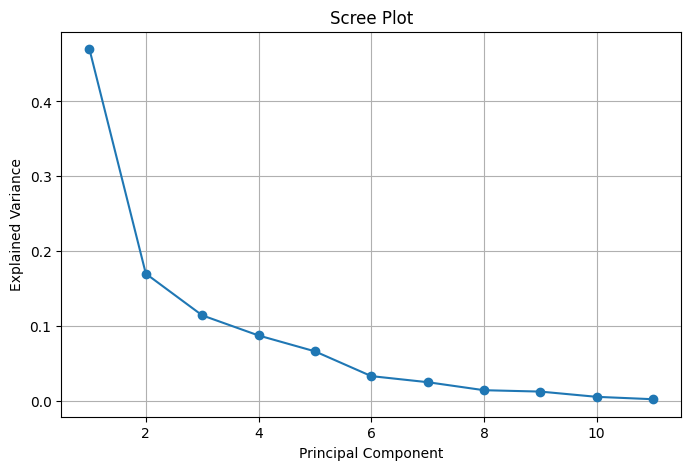

In [261]:
plt.figure(figsize=(8,5))

plt.plot(
    explained_01["PC"],
    explained_01["Explained Variance"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

### Cumulative plot 

Another plot that helps determine which Components I should keep 

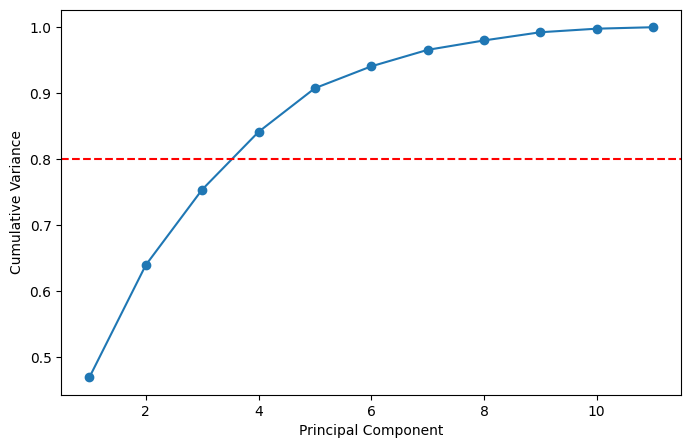

In [262]:
plt.figure(figsize=(8,5))

plt.plot(
    explained_01["PC"],
    explained_01["Cumulative"],
    marker="o"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

This shows the loadings of each Principal Component, for each component in my model, it shows the influence of the selected variables 

For example, PC1 leans more heavily towards variables that determin citizen freedom and trust in their government 

with Governance, Personal_Freedom, Media Literacy all scoring relatively equal scores in PC1

In [263]:
loadings_01 = pd.DataFrame(
    pca_01.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(len(features))
    ],
    index=features
)

print(loadings_01.round(3))

                        PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  \
Population            0.034  0.204  0.523  0.688 -0.369 -0.183  0.066  0.153   
Population_Density    0.058 -0.299  0.551 -0.590 -0.301 -0.243  0.023 -0.049   
GDP_Per_Capita        0.339 -0.180  0.102  0.107  0.530  0.033  0.621  0.136   
Unemployment         -0.021  0.628  0.207 -0.111  0.431 -0.006 -0.261 -0.072   
Tertiary_Enrollment   0.060  0.614 -0.171 -0.343 -0.299 -0.058  0.307  0.357   
Life_Expectancy       0.324  0.168  0.465 -0.100  0.179  0.259 -0.098 -0.358   
Media_Literacy_Index  0.386  0.007 -0.280  0.148 -0.209  0.033 -0.282 -0.417   
Governance            0.419 -0.033 -0.074  0.032  0.057 -0.407 -0.013  0.184   
Social_Capital        0.375 -0.107  0.056 -0.038 -0.163  0.671 -0.235  0.513   
Personal_Freedom      0.400 -0.035 -0.101 -0.043  0.136 -0.466 -0.384  0.234   
Education             0.383  0.152 -0.163 -0.038 -0.306  0.055  0.393 -0.411   

                        PC9   PC10   PC

Based on the findings from the Plots and the Loadings

I have decided to keep the first 4 Principal Components as they make up the 80% explained variance 

THese components also seem to have the most balanced influence from the selected variables while the latter components tend to have strong influence for one single variable and not much else

### PCA Selection

I selected the first 4 Components as the final PCA

In [264]:
pca_01 = PCA(n_components=4)

principal_components = pca_01.fit_transform(X_scaled)

### Adding PCA Components to a new Dataframe

Preparation for PCA Regression 01

In [265]:
pc_dataframe_01 = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2","PC3","PC4"]
)

pc_dataframe_01["Signatures_Per_Capita"] = master["Signatures_Per_Capita"]
pc_dataframe_01["Log_Signatures_Per_Capita"] = master["Log_Signatures_Per_Capita"]
pc_dataframe_01["Country"] = master["Country"]
pc_dataframe_01["Petition_ID"] = master["Petition_ID"]

### Correlations with Signatures Per Capita 

In [266]:
corr = pc_dataframe_01[
    ["PC1","PC2","PC3","PC4","Signatures_Per_Capita"]
].corr(method="spearman")

print(corr)

                            PC1       PC2       PC3       PC4  \
PC1                    1.000000  0.087912 -0.047009 -0.070818   
PC2                    0.087912  1.000000  0.003663 -0.115995   
PC3                   -0.047009  0.003663  1.000000  0.219780   
PC4                   -0.070818 -0.115995  0.219780  1.000000   
Signatures_Per_Capita  0.100476  0.034613  0.044369 -0.029666   

                       Signatures_Per_Capita  
PC1                                 0.100476  
PC2                                 0.034613  
PC3                                 0.044369  
PC4                                -0.029666  
Signatures_Per_Capita               1.000000  


### PCA Multi Linear Regression Model 01

In [267]:
X = pc_dataframe_01[["PC1","PC2","PC3","PC4"]]

y = pc_dataframe_01["Signatures_Per_Capita"]

In [268]:
import statsmodels.api as sm

X = sm.add_constant(X)

model_01 = sm.OLS(y, X).fit()

print(model_01.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.009
Model:                               OLS   Adj. R-squared:                  0.003
Method:                    Least Squares   F-statistic:                     1.634
Date:                   Sun, 09 Aug 2026   Prob (F-statistic):              0.164
Time:                           21:01:30   Log-Likelihood:                 3331.5
No. Observations:                    729   AIC:                            -6653.
Df Residuals:                        724   BIC:                            -6630.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008 

### PCA Regression Model 01 Evaluation

In [269]:
print("R²:", model_01.rsquared)
print("Adjusted R²:", model_01.rsquared_adj)
print("F-statistic:", model_01.fvalue)
print("Model p-value:", model_01.f_pvalue)

R²: 0.008948581996408245
Adjusted R²: 0.003473159797493297
F-statistic: 1.6343181715159254
Model p-value: 0.16372794765893453


### Predictions

In [270]:
predictions_01 = model_01.predict(X)

### RMSE

In [271]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(y, predictions_01)
)

print(rmse)

0.0025063747284414977


### MAE

In [272]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y,
    predictions_01
)

print(mae)

0.0011896871180916825


### Residual plots

In [273]:
residuals_01 = y - predictions_01

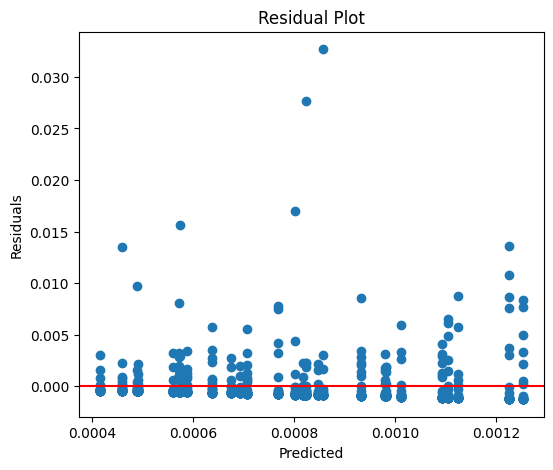

In [274]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_01, residuals_01)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

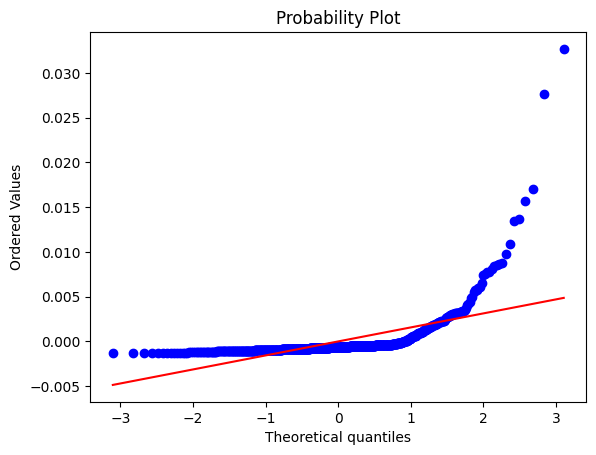

In [275]:
import scipy.stats as stats

stats.probplot(residuals_01, dist="norm", plot=plt)

plt.show()

### Interpretations

Interpretations of the PCA Regression

The PCA components while they flatten the dimensions of the country level variables very well

They fail to effectively explain variance in Signatures Per Capita

### PCA Log Linear Regression Model 01

In [276]:
X = pc_dataframe_01[["PC1","PC2","PC3","PC4"]]

y = pc_dataframe_01["Log_Signatures_Per_Capita"]

In [277]:
X = sm.add_constant(X)

log_model_01 = sm.OLS(y, X).fit()

print(log_model_01.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.009
Model:                                   OLS   Adj. R-squared:                  0.004
Method:                        Least Squares   F-statistic:                     1.650
Date:                       Sun, 09 Aug 2026   Prob (F-statistic):              0.160
Time:                               21:01:30   Log-Likelihood:                 3338.4
No. Observations:                        729   AIC:                            -6667.
Df Residuals:                            724   BIC:                            -6644.
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

### PCA Log Regression Model 01 Evaluation

In [278]:
print("R²:", log_model_01.rsquared)
print("Adjusted R²:", log_model_01.rsquared_adj)
print("F-statistic:", log_model_01.fvalue)
print("Model p-value:", log_model_01.f_pvalue)

R²: 0.00903120714150063
Adjusted R²: 0.003556241435100027
F-statistic: 1.649545883171944
Model p-value: 0.1599810110378655


### Feature Selection for PCA 02

This model will use the successful petitions dataset

In [279]:
features = [
    "Population",
    "Population_Density",
    "GDP_Per_Capita",
    "Unemployment",
    "Tertiary_Enrollment",
    "Life_Expectancy",
    "Media_Literacy_Index",
    "Governance",
    "Social_Capital",
    "Personal_Freedom",
    "Education"
]

X = successful_master[features]

### Normalising and Standardising the variables 

In [280]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### PCA 02

In [281]:
pca_02 = PCA()

principal_components = pca_02.fit_transform(X_scaled)

#### Explained Variance

In [282]:
explained_02 = pd.DataFrame({
    "PC": np.arange(1, len(features)+1),
    "Explained Variance":
        pca_02.explained_variance_ratio_,

    "Cumulative":
        np.cumsum(pca_02.explained_variance_ratio_)
})

print(explained_02)

    PC  Explained Variance  Cumulative
0    1            0.469838    0.469838
1    2            0.169978    0.639816
2    3            0.114279    0.754095
3    4            0.087379    0.841473
4    5            0.066185    0.907658
5    6            0.033083    0.940741
6    7            0.024971    0.965712
7    8            0.014258    0.979970
8    9            0.012414    0.992385
9   10            0.005403    0.997788
10  11            0.002212    1.000000


#### Scree Plot

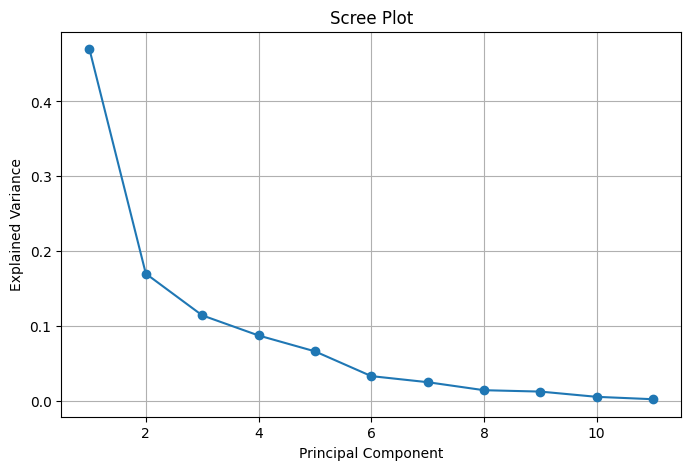

In [283]:
plt.figure(figsize=(8,5))

plt.plot(
    explained_02["PC"],
    explained_02["Explained Variance"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

#### Cumulative Plot

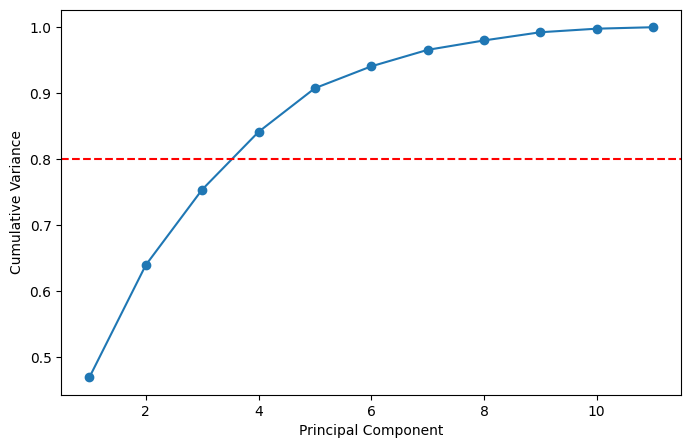

In [284]:
plt.figure(figsize=(8,5))

plt.plot(
    explained_02["PC"],
    explained_02["Cumulative"],
    marker="o"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

### Component Loadings

In [285]:
loadings_02 = pd.DataFrame(
    pca_02.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(len(features))
    ],
    index=features
)

print(loadings_02.round(3))

                        PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  \
Population            0.034  0.204  0.523  0.688 -0.369 -0.183  0.066  0.153   
Population_Density    0.058 -0.299  0.551 -0.590 -0.301 -0.243  0.023 -0.049   
GDP_Per_Capita        0.339 -0.180  0.102  0.107  0.530  0.033  0.621  0.136   
Unemployment         -0.021  0.628  0.207 -0.111  0.431 -0.006 -0.261 -0.072   
Tertiary_Enrollment   0.060  0.614 -0.171 -0.343 -0.299 -0.058  0.307  0.357   
Life_Expectancy       0.324  0.168  0.465 -0.100  0.179  0.259 -0.098 -0.358   
Media_Literacy_Index  0.386  0.007 -0.280  0.148 -0.209  0.033 -0.282 -0.417   
Governance            0.419 -0.033 -0.074  0.032  0.057 -0.407 -0.013  0.184   
Social_Capital        0.375 -0.107  0.056 -0.038 -0.163  0.671 -0.235  0.513   
Personal_Freedom      0.400 -0.035 -0.101 -0.043  0.136 -0.466 -0.384  0.234   
Education             0.383  0.152 -0.163 -0.038 -0.306  0.055  0.393 -0.411   

                        PC9   PC10   PC

### Component Selection

In [286]:
pca_02 = PCA(n_components=4)

principal_components = pca_02.fit_transform(X_scaled)

### PCA Regression Model 02

For this model I use the successful only dataset

In [287]:
pc_dataframe_02 = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2","PC3","PC4"]
)

pc_dataframe_02["Signatures_Per_Capita"] = successful_master["Signatures_Per_Capita"]
pc_dataframe_02["Log_Signatures_Per_Capita"] = successful_master["Log_Signatures_Per_Capita"]
pc_dataframe_02["Country"] = successful_master["Country"]
pc_dataframe_02["Petition_ID"] = successful_master["Petition_ID"]

### Correlations

In [288]:
corr = pc_dataframe_02[
    ["PC1","PC2","PC3","PC4","Signatures_Per_Capita"]
].corr(method="spearman")

print(corr)

                            PC1       PC2       PC3       PC4  \
PC1                    1.000000  0.087990 -0.047020 -0.070707   
PC2                    0.087990  1.000000  0.003547 -0.115949   
PC3                   -0.047020  0.003547  1.000000  0.219644   
PC4                   -0.070707 -0.115949  0.219644  1.000000   
Signatures_Per_Capita  0.319413  0.006919 -0.177375 -0.149713   

                       Signatures_Per_Capita  
PC1                                 0.319413  
PC2                                 0.006919  
PC3                                -0.177375  
PC4                                -0.149713  
Signatures_Per_Capita               1.000000  


### PCA Multi Linear Regression Model 02

In [289]:
X = pc_dataframe_02[["PC1","PC2","PC3","PC4"]]

y = pc_dataframe_02["Signatures_Per_Capita"]

In [290]:
X = sm.add_constant(X)

model_02 = sm.OLS(y, X).fit()

print(model_02.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.068
Model:                               OLS   Adj. R-squared:                  0.032
Method:                    Least Squares   F-statistic:                     1.877
Date:                   Sun, 09 Aug 2026   Prob (F-statistic):              0.120
Time:                           21:01:31   Log-Likelihood:                 423.77
No. Observations:                    108   AIC:                            -837.5
Df Residuals:                        103   BIC:                            -824.1
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0039 

### PCA Regression Model 02 Evaluation

In [291]:
print("R²:", model_02.rsquared)
print("Adjusted R²:", model_02.rsquared_adj)
print("F-statistic:", model_02.fvalue)
print("Model p-value:", model_02.f_pvalue)

R²: 0.06794540152606832
Adjusted R²: 0.03174910643970208
F-statistic: 1.8771369103922644
Model p-value: 0.12005046917782466


### Predictions

In [292]:
predictions_02 = model_02.predict(X)

### RMSE

In [293]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_02)
)

print(rmse)

0.004782934359889791


### MAE

In [294]:
mae = mean_absolute_error(
    y,
    predictions_02
)

print(mae)

0.002818238478091873


### Residual Plots

In [295]:
residuals_02 = y - predictions_02

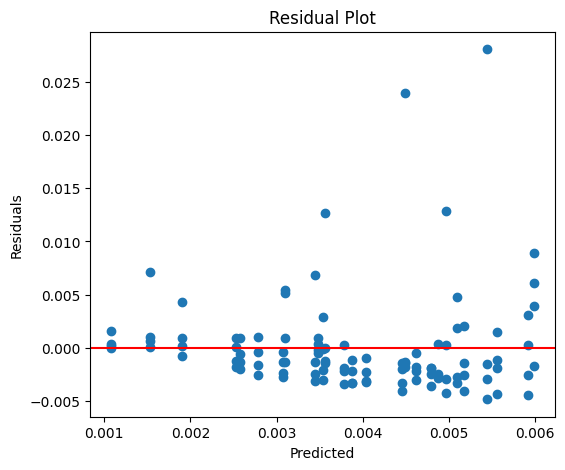

In [296]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_02, residuals_02)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

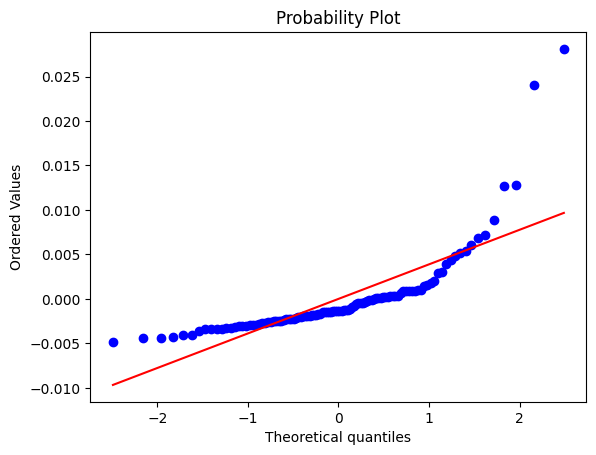

In [297]:
stats.probplot(residuals_02, dist="norm", plot=plt)

plt.show()

### Interpretations

Interpretations of the PCA Regression 02

Using the successful only dataset

Performs slightly better on the data when it only uses successful datasets

with an Rsquared of 0.068 which is slightly higher than the first model which has 0.009

### PCA Log Linear Regression Model 02

In [298]:
X = pc_dataframe_02[["PC1","PC2","PC3","PC4"]]

y = pc_dataframe_02["Log_Signatures_Per_Capita"]

In [299]:
X = sm.add_constant(X)

log_model_02 = sm.OLS(y, X).fit()

print(log_model_02.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.134
Model:                                   OLS   Adj. R-squared:                  0.100
Method:                        Least Squares   F-statistic:                     3.987
Date:                       Sun, 09 Aug 2026   Prob (F-statistic):            0.00477
Time:                               21:01:31   Log-Likelihood:                -140.07
No. Observations:                        108   AIC:                             290.1
Df Residuals:                            103   BIC:                             303.5
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

### PCA Log Regression Model 02 Evaluation

In [300]:
print("R²:", log_model_02.rsquared)
print("Adjusted R²:", log_model_02.rsquared_adj)
print("F-statistic:", log_model_02.fvalue)
print("Model p-value:", log_model_02.f_pvalue)

R²: 0.13406089249720887
Adjusted R²: 0.10043218929321696
F-statistic: 3.9865019975345106
Model p-value: 0.004769283252752825


### Export

#### Export Outputs

#### PCA 01

In [301]:
explained_01.to_csv(
    rf"{output_path}/pca/explained_variance_01.csv",
    index=False
)

loadings_01.to_csv(
    rf"{output_path}/pca/component_loadings_01.csv"
)

#### PCA 02

In [302]:
explained_02.to_csv(
    rf"{output_path}/pca/explained_variance_02.csv",
    index=False
)

loadings_02.to_csv(
    rf"{output_path}/pca/component_loadings_02.csv"
)

#### Export Models

#### PCA Model 01

In [303]:
# https://apxml.com/courses/basics-ml-deployment/chapter-2-preparing-model-deployment/using-joblib-persistence

joblib.dump(
    pca_01,
    rf"{model_path}/pca/pca_model_01.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_model_01.pkl']

#### PCA Model 02

In [304]:
joblib.dump(
    pca_02,
    rf"{model_path}/pca/pca_model_02.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_model_02.pkl']

### PCA Regression Model 01

In [305]:
joblib.dump(
    model_01,
    rf"{model_path}/pca/pca_regression_model_01.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_regression_model_01.pkl']

### PCA Log Regression Model 01

In [306]:
joblib.dump(
    log_model_01,
    rf"{model_path}/pca/pca_log_regression_model_01.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_log_regression_model_01.pkl']

### PCA Regression Model 02

In [307]:
joblib.dump(
    model_02,
    rf"{model_path}/pca/pca_regression_model_02.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_regression_model_02.pkl']

### PCA Log Regression Model 02

In [308]:
joblib.dump(
    log_model_02,
    rf"{model_path}/pca/pca_log_regression_model_02.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/pca/pca_log_regression_model_02.pkl']